# Lesson 6: Your first language model (the bigram)

**Why:** we now have all the pieces: tokenizer (L4), batches (L5), lookup table + softmax + loss (L3), and the training loop (L2). Put together, they make a real (if simple) language model.

**The bigram idea:** predict the next character by looking at **only the current one**. "After `q` comes `u`." "After a space, `t` is likely." It's a table of 85 × 85 scores:

```
current char ──lookup row──► 85 scores ──softmax──► probabilities for the next char
idx (B, T)                   logits (B, T, 85)
```

It's simple on purpose. It gets the **whole pipeline** working end to end. Lessons 7–10 then make the middle smarter.

## 1. Setup (from Lessons 4 and 5)

In [1]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(1337)

text = Path("../data/input.txt").read_text(encoding="utf-8")
chars = sorted(set(text))
V = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

batch_size, block_size = 32, 8   # B, T

def get_batch(split):
    source = train_data if split == "train" else val_data
    starts = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i : i + block_size] for i in starts])
    y = torch.stack([source[i + 1 : i + block_size + 1] for i in starts])
    return x, y

print(f"V={V}, training chars={len(train_data):,}")

V=85, training chars=878,944


## 2. The old-fashioned way: just count

Before any neural network, the simplest bigram model is a **counting table**: how often does each character follow each other character in the training text? Turn the counts into probabilities, and that's the model.

Its loss on the validation text is the **best a bigram can possibly do**. Our neural version should end up close to it.

In [2]:
counts = torch.zeros(V, V)
counts.index_put_((train_data[:-1], train_data[1:]), torch.ones(n - 1), accumulate=True)
probs_table = (counts + 1) / (counts + 1).sum(dim=1, keepdim=True)   # +1 so nothing is impossible

val_pairs = probs_table[val_data[:-1], val_data[1:]]
count_loss = -val_pairs.log().mean().item()
print(f"counting model, validation loss: {count_loss:.3f}")

for ch in ["q", "t", " "]:
    top = probs_table[stoi[ch]].topk(3)
    nxt = ", ".join(f"{decode([i.item()])!r} {p.item():.0%}" for p, i in zip(top.values, top.indices))
    print(f"after {ch!r}: {nxt}")

counting model, validation loss: 2.406
after 'q': 'u' 93%, ' ' 0%, '!' 0%
after 't': 'h' 32%, ' ' 16%, 'i' 11%
after ' ': 't' 17%, 'a' 11%, 'o' 9%


## 3. The neural version

Now the same thing as a **neural network** that learns the table by gradient descent (Lesson 2) instead of counting. This matters because the same training method will later train the full GPT, where counting is impossible.

A model in PyTorch is a **class**: a bundle of parameters plus a `forward` method that says how to compute the output. (`super().__init__()` is required setup; just copy it.)

- **`forward`**: look up scores, and if answers are given, compute the loss. `F.cross_entropy` wants a flat list of (examples, V), so we flatten (B, T, V) → (B·T, V) with `.view`, as in Lesson 1.
- **`generate`**: write text one character at a time. Look at the **last** position's scores → softmax → roll the dice → append → repeat.

In [3]:
class BigramLanguageModel(nn.Module):
    def __init__(self, V):
        super().__init__()
        self.table = nn.Embedding(V, V)           # row = current char, 85 scores for the next

    def forward(self, idx, targets=None):
        logits = self.table(idx)                  # (B, T) -> (B, T, V)
        if targets is None:
            return logits, None
        B, T, V = logits.shape
        loss = F.cross_entropy(logits.view(B * T, V), targets.view(B * T))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx)                 # (B, T, V)
            last = logits[:, -1, :]               # (B, V)  scores after the last char
            probs = F.softmax(last, dim=-1)       # (B, V)
            nxt = torch.multinomial(probs, 1)     # (B, 1)  roll the dice
            idx = torch.cat([idx, nxt], dim=1)    # (B, T+1)
        return idx

model = BigramLanguageModel(V)
print("parameters:", sum(p.numel() for p in model.parameters()))

parameters: 7225


## 4. Before training

**Predict:** in Lesson 3 we said a know-nothing model has a loss of **4.44**. This fresh model's scores are random. Will its loss be exactly 4.44, a bit lower, or a bit higher?

Then we let the untrained model write 200 characters, starting from a newline (id 0).

In [4]:
xb, yb = get_batch("train")
logits, loss = model(xb, yb)
print("logits shape:", logits.shape)
print(f"loss before training: {loss.item():.3f}   (know-nothing target: 4.44)")

start = torch.zeros((1, 1), dtype=torch.long)
print("\n--- untrained model writes ---")
print(decode(model.generate(start, 200)[0].tolist()))

logits shape: torch.Size([32, 8, 85])
loss before training: 4.999   (know-nothing target: 4.44)

--- untrained model writes ---

DN/6wth4Jg-Cup=V!-:+3L=wIbKFQ*rnESC7JO44i^IxIWmlJSJ1KNDNuuP?o*A9U=&Cw{{[MXQd)8XCjPOswhJGu*!r/TPkfn5cWsMEq2N)T^I6'{L"4EMVLK3h,x{]]g83/6pr"&y0tSlplx}'.q=I]M=hroRvdOr^tXgr[sHS36=K7ZBps6iHOq0Jjlc+m0:ZiWQm


## 5. Training

The Lesson 2 loop, with two upgrades:
- **AdamW**: a smarter optimizer that adapts the step size for each parameter separately (remember the exploding `b` in Lesson 2?).
- **`estimate_loss`**: every 500 steps, average the loss over 100 batches of **training** and **validation** text. A single batch is too noisy to judge by. (`model.eval()` / `@torch.no_grad()` mean "just measuring, don't learn".)

In [5]:
@torch.no_grad()
def estimate_loss(model, eval_batches=100):
    model.eval()
    result = {}
    for split in ["train", "val"]:
        losses = [model(*get_batch(split))[1].item() for _ in range(eval_batches)]
        result[split] = sum(losses) / len(losses)
    model.train()
    return result

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2)
history = []

for step in range(5001):
    if step % 500 == 0:
        l = estimate_loss(model)
        print(f"step {step:5d}:  train {l['train']:.3f}   val {l['val']:.3f}")
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)            # 1-2. forward + loss
    optimizer.zero_grad()              # 3.
    loss.backward()                    # 4.
    optimizer.step()                   # 5.
    history.append(loss.item())

step     0:  train 4.989   val 4.983


step   500:  train 2.543   val 2.549


step  1000:  train 2.444   val 2.446


step  1500:  train 2.413   val 2.437


step  2000:  train 2.412   val 2.414


...

step  3000:  train 2.400   val 2.406


step  3500:  train 2.390   val 2.399


step  4000:  train 2.398   val 2.401


step  4500:  train 2.383   val 2.402


step  5000:  train 2.391   val 2.408


## 6. See the learning, then read its writing

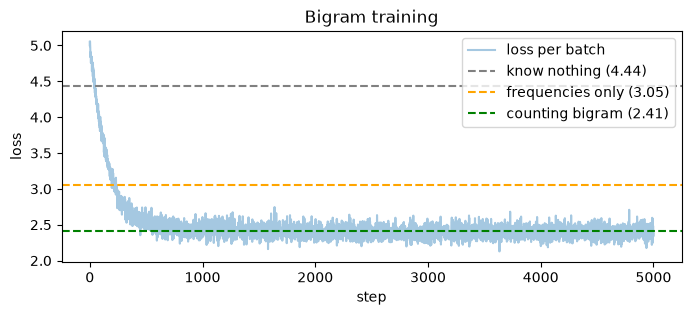

--- trained model writes ---


tlboan ralumit feilued omelerve RATh, midurpencasermery ndene, by by at geras t ctherk s fy, f ongr IZQUThre theerig revamof, ece pedit hes hsums ogasty tolds e in ope lmus
sthefrio t g deldrmumaschermoustsowobe cefithort onubeme th co ay inon a athe
ig s fiand okinsec w t wh
by a wegimantsonte s. st thond of tutin E churblewineat t buf s a, r
cunghe
aby aringeron rfor illimpe bysung ait g tisale


In [6]:
plt.figure(figsize=(8, 3))
plt.plot(history, alpha=0.4, label="loss per batch")
plt.axhline(4.44, color="gray", ls="--", label="know nothing (4.44)")
plt.axhline(3.05, color="orange", ls="--", label="frequencies only (3.05)")
plt.axhline(count_loss, color="green", ls="--", label=f"counting bigram ({count_loss:.2f})")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("Bigram training"); plt.show()

print("--- trained model writes ---")
print(decode(model.generate(start, 400)[0].tolist()))

## 7. Final check

In [7]:
final = estimate_loss(model, eval_batches=200)
print(f"neural bigram val loss: {final['val']:.3f}   counting bigram: {count_loss:.3f}")
assert final["val"] < 3.05, "should beat the frequency-only model"
assert abs(final["val"] - count_loss) < 0.1, "neural and counting bigram should roughly agree"
print("Lesson 6 complete. Your first language model works!")

neural bigram val loss: 2.406   counting bigram: 2.406
Lesson 6 complete. Your first language model works!


## Wrap-up question

Read the trained model's text. What has it learned (look at word lengths, spaces, capitals, punctuation)? What is it clearly missing, and why, given that it only ever looks at **one** character?